In [1]:
#LIBRARY
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting 
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier                                                                                                           
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)                   
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import math
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, GaussianNoise
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
from sklearn.preprocessing import StandardScaler, MinMaxScaler
%run useful.py
import tensorflow.random as tf_r
import tensorflow as tf
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from sklearn.preprocessing import StandardScaler
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

XGBoost version: 3.2.0


I0000 00:00:1778777980.190110   11205 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778777980.236775   11205 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778777981.360737   11205 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13
np.random.seed(12345)

path = "./DATA/all_data.csv"

feature_names = ['f1', 'f2', 'f3', 'f4', 'f5', 
                 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12']


df = pd.read_csv(path, names=feature_names + ['class'], header=None)

df['class'] = df['class'].astype(str).map({'1': 1, '0': 0})

df = df.dropna()

x = df[feature_names].values
y = df['class'].values.astype(int) 

N = len(x)         
L = len(x[0])      

print(f"N (samples) = {N}")
print(f"L (features) = {L}") 
print("\nPrime righe del dataset:")
print(df.head())

N (samples) = 230
L (features) = 12

Prime righe del dataset:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train_val, x_test, y_train_val, y_test = train_test_split(
    x, y, test_size=0.20, stratify=y, random_state=12345
)

scaler = StandardScaler()
x_train_val = scaler.fit_transform(x_train_val)
x_test = scaler.transform(x_test)

x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_val, y_train_val, test_size=0.20, stratify=y_train_val, random_state=12345
)

#IPER-PARAMETERS
l_rates = [0.1 , 0.01, 0.001]
b_sizes = [32, 64]
opts = ['SGD', 'RMSprop', 'Adam']
n_epochs = 500

n_combinations = len(l_rates) * len(b_sizes) * len(opts)
n_cols = 3
n_rows = math.ceil(n_combinations / n_cols)
#fig_ind, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
#axes = axes.flatten()

best_acc = 0
results_history = [] 


Epoch 1/500


/home/niccolo/.local/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6599 - loss: 0.6142 - val_accuracy: 0.7297 - val_loss: 0.5515
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8980 - loss: 0.2894 - val_accuracy: 0.7297 - val_loss: 0.4946
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8844 - loss: 0.2473 - val_accuracy: 0.7568 - val_loss: 0.4543
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8980 - loss: 0.2250 - val_accuracy: 0.8378 - val_loss: 0.4071
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9116 - loss: 0.1695 - val_accuracy: 0.8649 - val_loss: 0.3834
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9524 - loss: 0.1676 - val_accuracy: 0.8919 - val_loss: 0.3489
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9388 - loss: 0.1841 - val_accuracy: 0.8649 - val_loss: 0.3345
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9320 - loss: 0.1679 - val_accuracy: 0.8919 - val_loss: 0.3277
Epoc

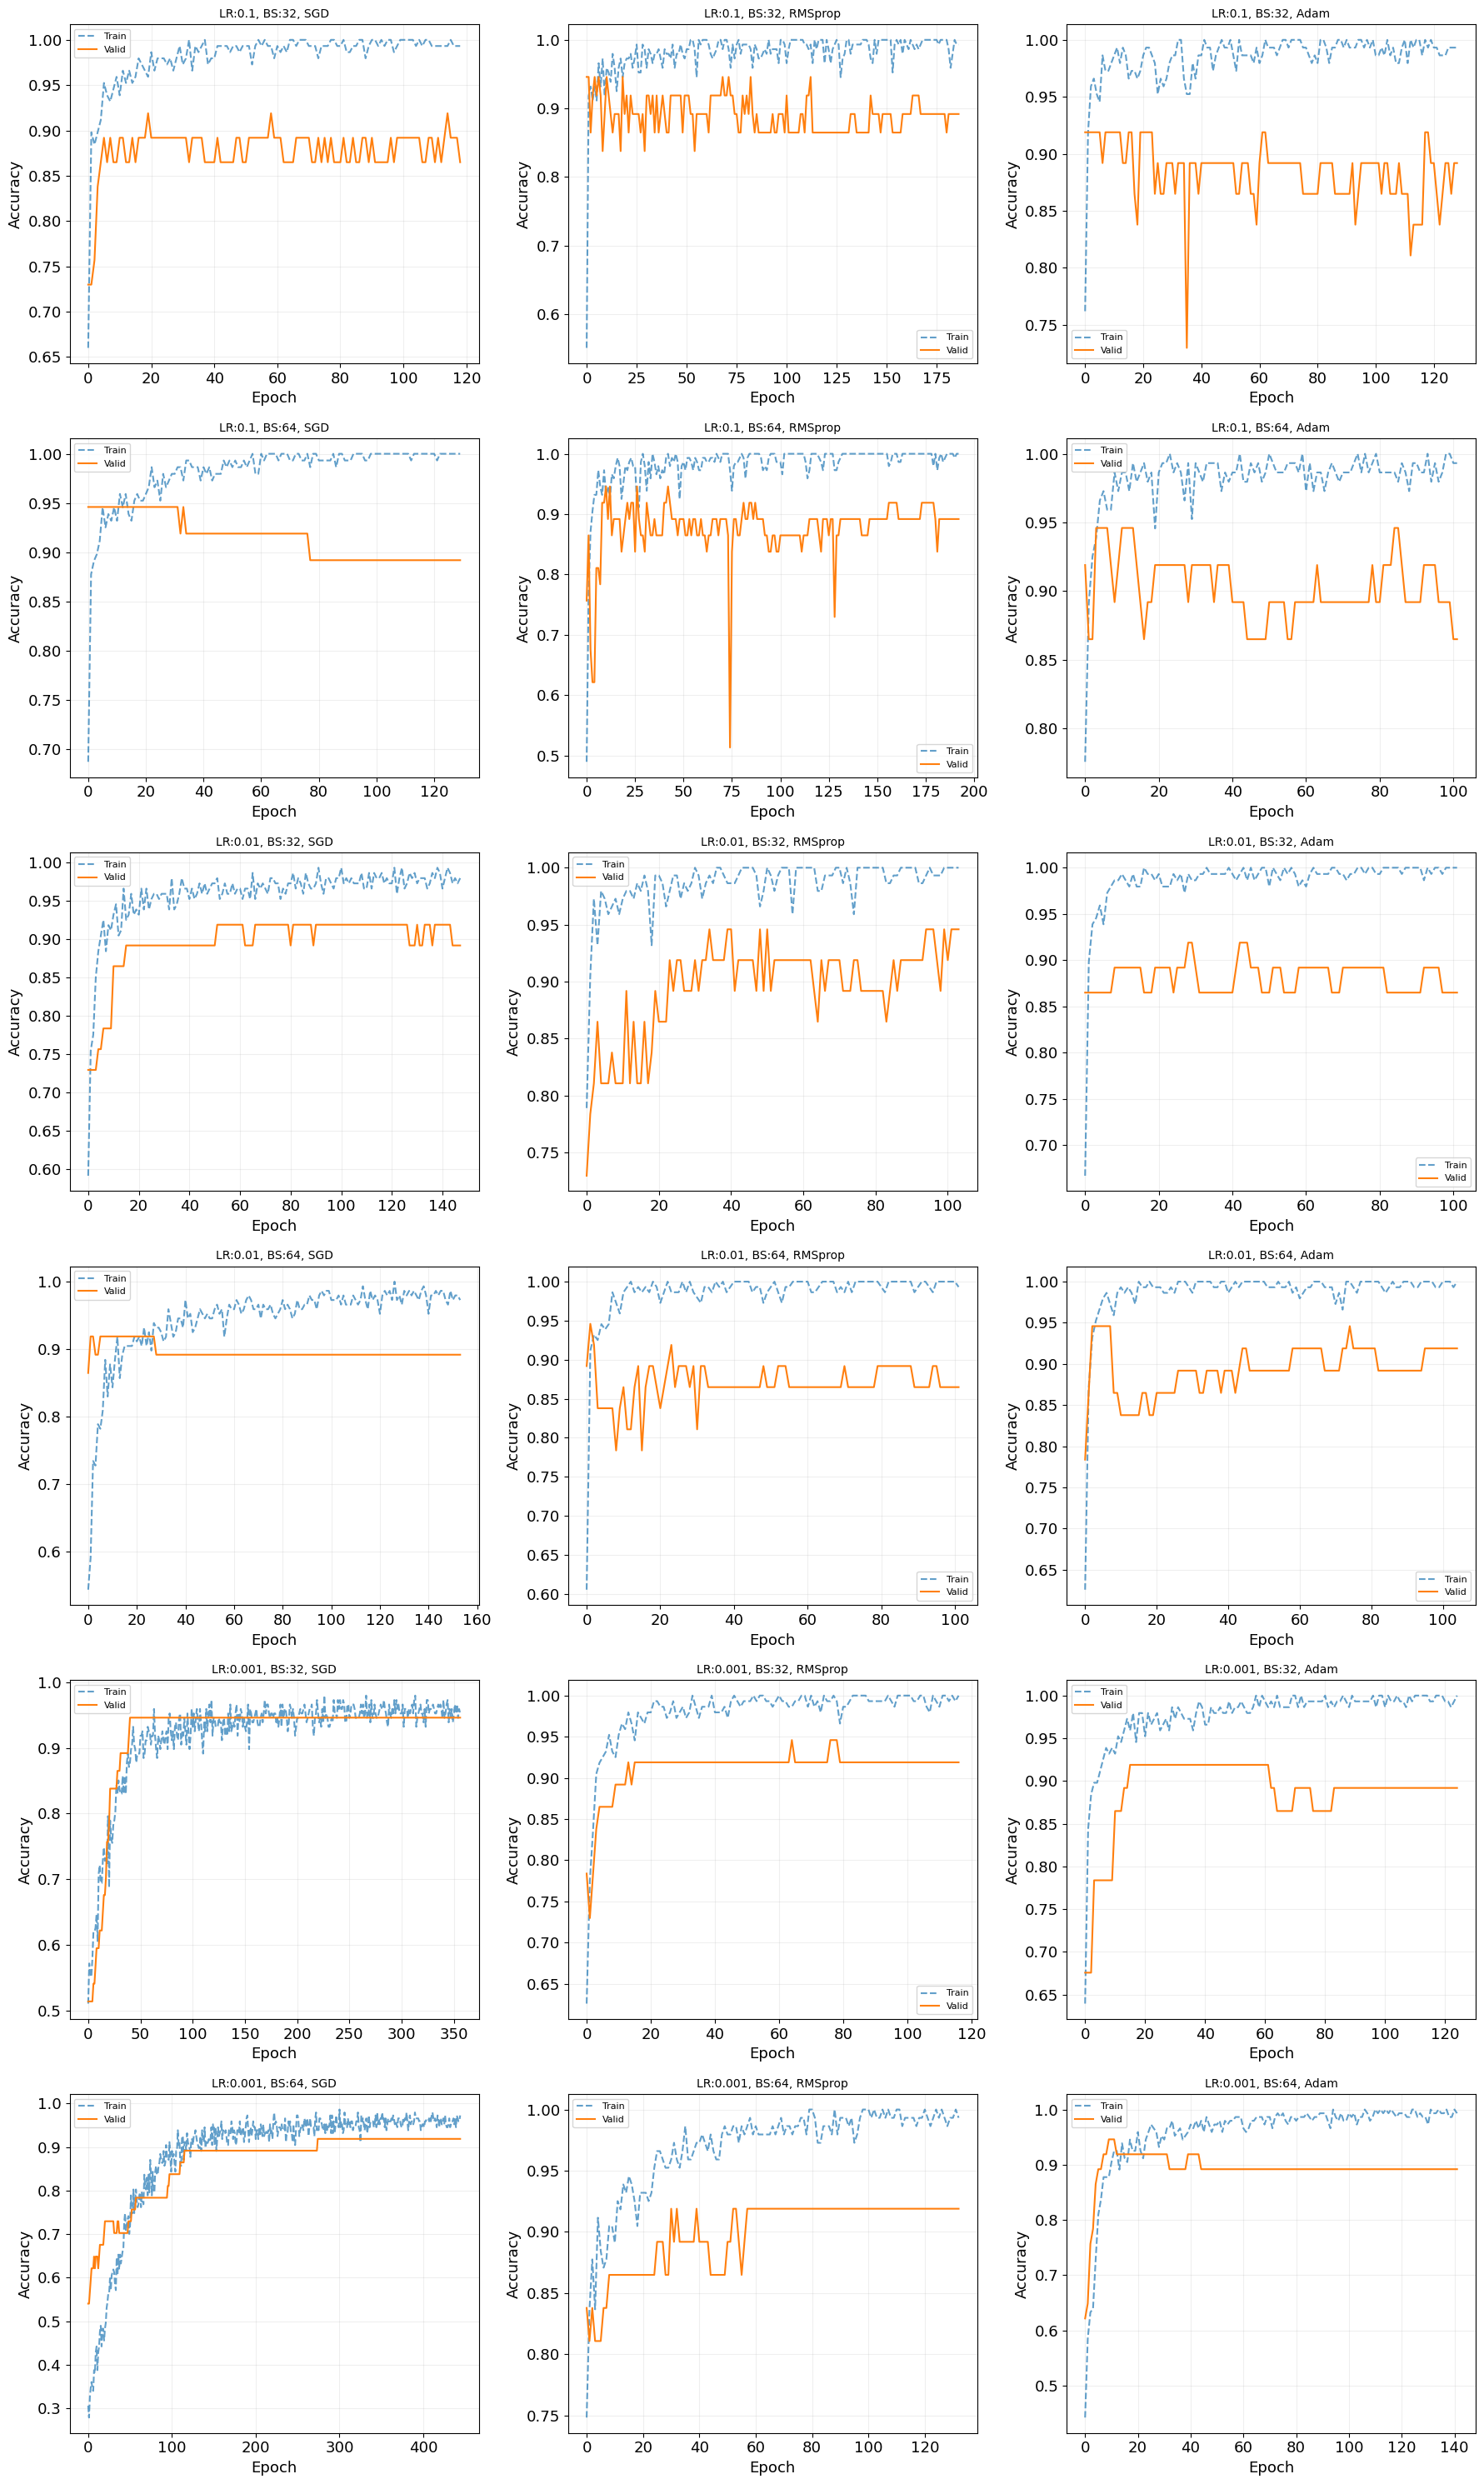

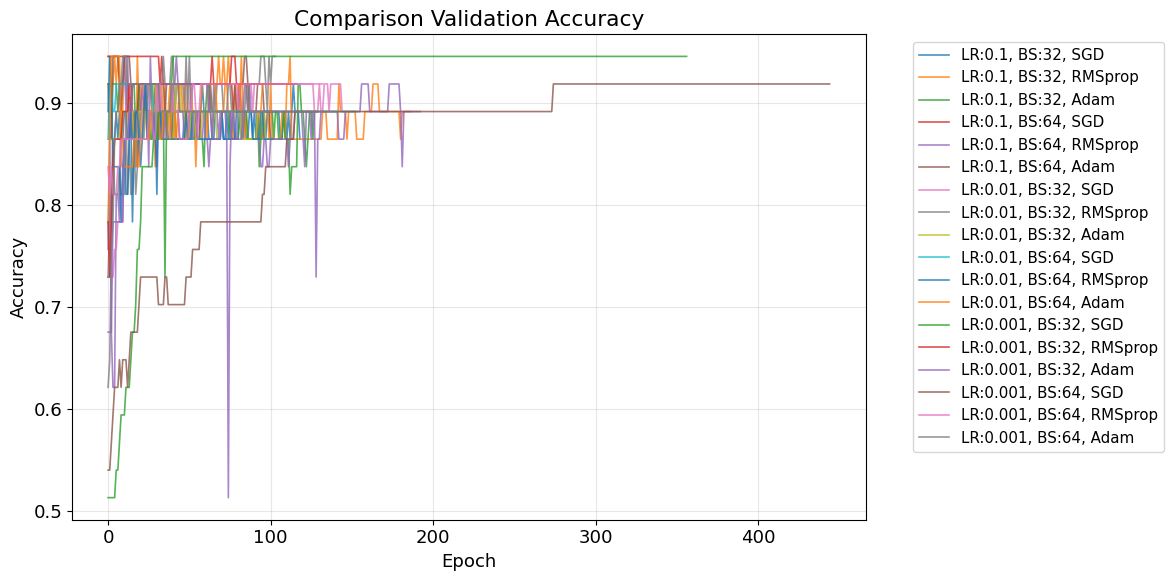


FINAL RESULT:
Best Configuration: LR:0.1, BS:32, RMSprop
Test Accuracy: 0.9565


In [ ]:
# EARLY STOPPING - BATCH NORM - AUGMENTATION
n_combinations = len(l_rates) * len(b_sizes) * len(opts)
n_cols = 3
n_rows = math.ceil(n_combinations / n_cols)

# Creazione della figura e della griglia di sotto-grafici
fig_ind, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()


best_acc = 0
results_history = []

for i, lr in enumerate(l_rates):
    for j, bs in enumerate(b_sizes):
        for k, opt_name in enumerate(opts):
            
            idx = i * (len(b_sizes) * len(opts)) + j * len(opts) + k
            label = f"LR:{lr}, BS:{bs}, {opt_name}"
            
            tf.random.set_seed(12345)
            np.random.seed(12345)

            model = Sequential([
                # DATA AUGMENTATION (Noise)
                GaussianNoise(0.1, input_shape=(L,)), 
                Dense(L, activation='relu'),
                # BATCH NORMALIZATION
                BatchNormalization(),
                Dense(20, activation="elu"),
                BatchNormalization(),
                Dropout(0.1),
                Dense(20, activation="elu"),
                BatchNormalization(),
                Dropout(0.1),
                Dense(20, activation='elu'),
                BatchNormalization(),
                Dropout(0.1),
                Dense(1, activation='sigmoid')
            ])

            if opt_name == 'Adam': optimizer = Adam(learning_rate=lr)
            elif opt_name == 'RMSprop': optimizer = RMSprop(learning_rate=lr)
            else: optimizer = SGD(learning_rate=lr)

            model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

            # EARLY STOPPING
            early_stop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

            fit = model.fit(
                x_train, y_train,
                epochs=n_epochs,
                batch_size=bs,
                validation_data=(x_valid, y_valid),
                verbose=1,
                callbacks=[early_stop]
            )

            val_acc_final = max(fit.history['val_accuracy'])
            results_history.append({'label': label, 'val_acc': fit.history['val_accuracy']})

            if val_acc_final > best_acc:
                best_acc = val_acc_final
                best_model = model
                best_params_label = label

            ax = axes[idx]
            ax.plot(fit.history['accuracy'], label="Train", ls="--", alpha=0.7)
            ax.plot(fit.history['val_accuracy'], label="Valid")
            ax.set_title(label, fontsize=10)
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Accuracy")
            ax.grid(True, alpha=0.2)
            ax.legend(prop={'size': 8})

for i in range(idx + 1, len(axes)):
    fig_ind.delaxes(axes[i])

fig_ind.tight_layout()
plt.show()

test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)

plt.figure(figsize=(12, 6))
for res in results_history:
    plt.plot(res['val_acc'], label=res['label'], lw=1.2, alpha=0.8)
plt.title("Comparison Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFINAL RESULT:\nBest Configuration: {best_params_label}")
print(f"Test Accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


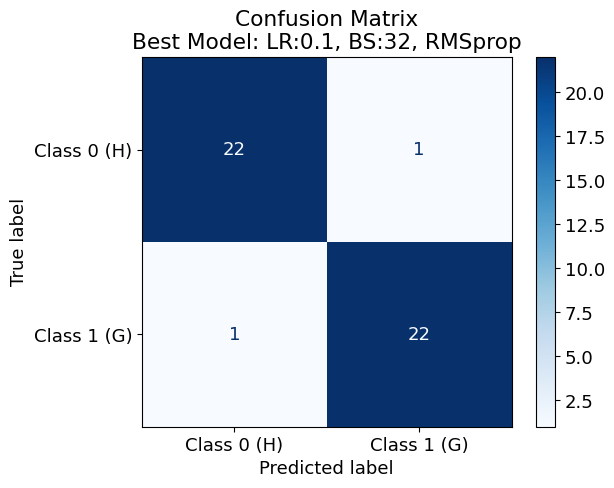


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Class 0 (H)       0.96      0.96      0.96        23
 Class 1 (G)       0.96      0.96      0.96        23

    accuracy                           0.96        46
   macro avg       0.96      0.96      0.96        46
weighted avg       0.96      0.96      0.96        46



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_probs = best_model.predict(x_test) 
y_pred = (y_probs.flatten() > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0 (H)', 'Class 1 (G)'])
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title(f"Confusion Matrix\nBest Model: {best_params_label}")
plt.grid(False) 
plt.show()

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Class 0 (H)', 'Class 1 (G)']))

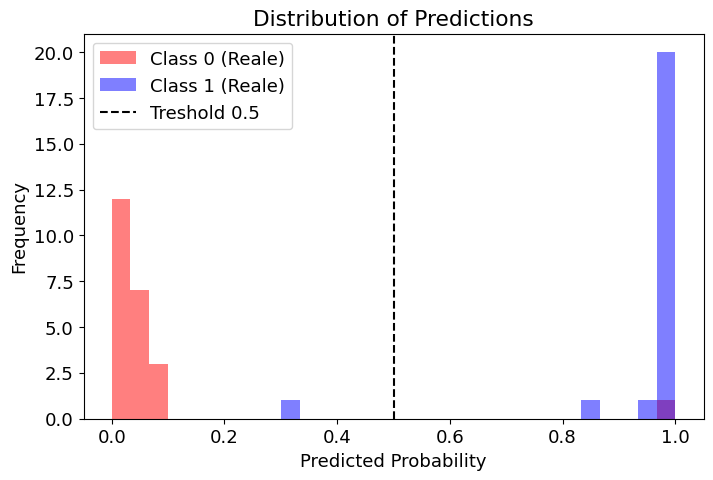

In [ ]:
y_probs_flat = y_probs.ravel() 

plt.figure(figsize=(8, 5))
# Aggiungi range=(0,1) per essere sicuro di vedere l'intero spettro
plt.hist(y_probs_flat[y_test==0], bins=30, alpha=0.5, label='Class 0 (Reale)', color='red', range=(0,1))
plt.hist(y_probs_flat[y_test==1], bins=30, alpha=0.5, label='Class 1 (Reale)', color='blue', range=(0,1))

plt.axvline(0.5, color='black', linestyle='--', label='Treshold 0.5')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Predictions')
plt.legend()
plt.show()

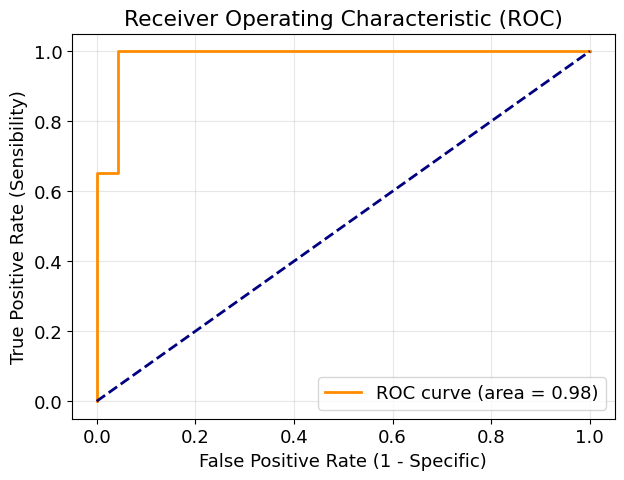

In [18]:
from sklearn.metrics import roc_curve, auc


fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specific)')
plt.ylabel('True Positive Rate (Sensibility)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


<Figure size 800x600 with 0 Axes>

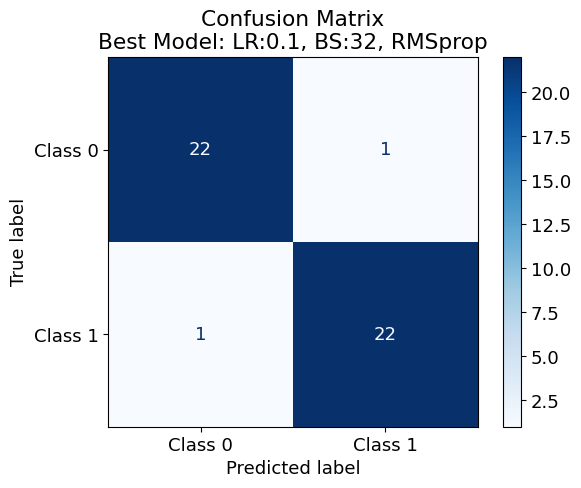


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        23
           1       0.96      0.96      0.96        23

    accuracy                           0.96        46
   macro avg       0.96      0.96      0.96        46
weighted avg       0.96      0.96      0.96        46



In [ ]:
y_probs = best_model.predict(x_test) 
y_pred = (y_probs > 0.4831).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title(f"Confusion Matrix\nBest Model: {best_params_label}")
plt.show()

from sklearn.metrics import classification_report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))